# Tass bow softmax lexical glove classification:

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import sys
import re
import gzip
import shutil
import unittest
import importlib
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from nltk.tokenize import TweetTokenizer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import ShuffleSplit, StratifiedKFold, cross_validate
from sklearn.utils import resample


DRIVE_PATH = '/content/drive/MyDrive/NLP_TASS'
sys.path.append('/content/drive/MyDrive/NLP_TASS')
os.chdir(DRIVE_PATH)

import feature_extraction
from feature_extraction import FeatureExtraction

# 1. Cargar datasets de TASS 2018
data_train = pd.read_csv(os.path.join(DRIVE_PATH, 'tass2018_es_train.csv'))
data_test = pd.read_csv(os.path.join(DRIVE_PATH, 'tass2018_es_test.csv'))

glove_path = os.path.join(DRIVE_PATH, 'glove-sbwc.i25.vec')

gz_path = os.path.join(DRIVE_PATH, 'glove-sbwc.i25.vec.gz')
if not os.path.exists(glove_path) and os.path.exists(gz_path):
    print("Descomprimiendo GloVe desde Drive...")
    with gzip.open(gz_path, 'rb') as f_in:
        with open(glove_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NLP_TASS'

### Fase 0

Verificar si es constante

In [ ]:
# Extraer la matriz de características X con FeatureExtraction
fe = FeatureExtraction(lang='es')
X_features = np.array([fe.get_features(str(text)) for text in data_train['content']])

# Lista de nombres de las 29 características
feature_names = [
    'weighted_position', 'weighted_normalized', 'label_mention', 'label_url',
    'label_hashtag', 'label_emoji', 'label_retweets', 'lexical_diversity',
    'label_word', 'first_person_singular', 'second_person_singular',
    'third_person_singular', 'first_person_plurar', 'second_person_plurar',
    'third_person_plurar', 'avg_word', 'kur_word', 'skew_word',
    'adverb_neg', 'adverb_time', 'adverb_place', 'adverb_mode',
    'adverb_cant', 'adverb_all', 'adjetives_neg', 'adjetives_pos',
    'who_general', 'who_male', 'who_female'
]
# Analizar constancia sobre la matriz de características extraídas
constantes_info = []

for i, name in enumerate(feature_names):
    feature_vec = X_features[:, i]

    # Métrica 1: Desviación estándar
    std_val = np.std(feature_vec)

    # Métrica 2: Cantidad de valores únicos en todo el conjunto de datos
    unique_vals = np.unique(feature_vec)

    # Es constante si la desviación estándar es 0 (o solo tiene 1 valor único)
    es_constante = (std_val == 0) or (len(unique_vals) == 1)

    constantes_info.append({
        'Característica': name,
        '¿Es constante?': 'SÍ' if es_constante else 'No',
        'Desviación Estándar': round(std_val, 4),
        'Valores Únicos': unique_vals if len(unique_vals) <= 3 else f"{len(unique_vals)} valores distintos"
    })

df_constantes = pd.DataFrame(constantes_info)
df_constantes

 Correlación con Longitud ( r  con  Ntokens )

In [ ]:
# Instanciar tokenizador
tokenizer = TweetTokenizer()

# Calcular número de tokens por tweet (N_tokens)
n_tokens = data_train['content'].apply(lambda x: len(tokenizer.tokenize(str(x)))).values

#  Calcular correlación de Pearson r para cada característica con N_tokens
correlations = {}
for i, name in enumerate(feature_names):
    feature_vec = X_features[:, i]
    if np.std(feature_vec) == 0:
        r = 0.0
    else:
        r = np.corrcoef(feature_vec, n_tokens)[0, 1]
    correlations[name] = round(r, 3)

# Visualizar la tabla de resultados
df_correlaciones = pd.DataFrame(list(correlations.items()), columns=['Característica', 'r_con_Ntokens'])
df_correlaciones

1. Análisis cualitativo y diagnóstico de la implementación

* Orden del Preprocesamiento vs. Símbolos (Emojis, Hashtags, Menciones): TextProcessing.transformer ejecuta la función proper_encoding (conversión NFD $\rightarrow$ ASCII eliminando caracteres especiales/no-ASCII) antes de la búsqueda de emojis. Esto destruye los caracteres Unicode de los emojis antes de ser detectados, haciendo que la etiqueta [EMOJI] nunca se emita.   La sustitución de hashtags emite la cadena errónea "hastag" en lugar de "hashtag". Como FeatureExtraction busca explícitamente el token "hashtag", la coincidencia falla en el 100% de los casos.   

* Acentos y Normalización NFD: La función proper_encoding elimina las tildes y la $\tilde{n}$ (por ejemplo, más pasa a mas, niño a nino). Sin embargo, los diccionarios de lexical_es contienen entradas con tildes (como más, músico, pésimo). Al limpiar el texto, un 13.8% de las palabras del diccionario se vuelven completamente inalcanzables.

* Incompatibilidad de Tokens Múltiples (Bigramas / Frases): El contador compara token por token. Entradas formadas por varias palabras como "en absoluto" o "bestia negra" jamás se activarán mediante esta tokenización simple

* Ambigüedad Gramatical y Semántica: Determinantes y artículos como "el", "mi" o "tu" están catalogados como pronombres personales de primera o tercera persona. Cada vez que aparece el artículo definido "el", se contabiliza erróneamente un pronombre personal.   Los diccionarios adjetives_neg y adjetives_pos contienen palabras ambiguas o neutras (colores, tamaños) y solapan 6 adjetivos que están presentes simultáneamente en ambas listas (ej. caliente, diferente, duro, imposible, popular, salado)

* Métricas de Longitud y Posición: weighted_position y weighted_normalized se calculan sobre índices de tokens. weighted_normalized equivale algebraicamente a $\frac{n+1}{2}$, siendo una función lineal exacta del número de tokens.   lexical_diversity calcula la proporción de caracteres únicos sobre el total de caracteres del mensaje, en lugar de una tasa Tipo/Token (Type-Token Ratio) sobre términos/palabras.




2. Reporte Cuantitativo en el Corpus TASS

| Característica (`feature_name`) | (a) ¿Es constante? | (b) Correlación con Longitud ($r$ con $N_{\text{tokens}}$) | (c) ¿Desactivada por preprocesamiento? | Decisión / Corrección propuesta |
| --- | --- | --- | --- | --- |
| `weighted_position` | No | 0.896 | No | **Modificar:** Reemplazar por posición relativa real del primer término polar. |
| `weighted_normalized` | No | 0.986 | No | **Excluir:** Redundante; es un proxy directo de la longitud ($r \approx 1.0$).
 |
| `label_mention` | **SÍ** | 0.000 | **SÍ** | **Corregir:** Revisar el regex/patrón de detección de `@usuario`. |
| `label_url` | **SÍ** | 0.000 | **SÍ** | **Corregir:** Revisar el regex/patrón de detección de enlaces (`http/https`). |
| `label_hashtag` | **SÍ** | 0.000 | **SÍ** | **Corregir:** Corregir errata en el tokenizador que emite `"hastag"` en vez de `"hashtag"`.
 |
| `label_emoji` | **SÍ** | 0.000 | **SÍ** | **Corregir:** Mover la extracción de emojis antes de la normalización ASCII (NFD).
 |
| `label_retweets` | No | -0.028 | No | **Mantener:** Detecta presencia de marcas "RT". |
| `lexical_diversity` | No | -0.818 | No | **Corregir:** Cambiar cálculo a diversidad léxica por palabras ($\frac{\text{palabras únicas}}{\text{total palabras}}$). |
| `label_word` | No | 1.000 | No | **Excluir:** Conteo plano de tokens, $100\%$ redundante ($r = 1.0$). |
| `first_person_singular` | No | 0.123 | Parcial (pierde tildes)| **Corregir:** Mantener acentos/ñ en el texto o lematizar; filtrar artículos ambiguos (*mi*).
  |
| `second_person_singular` | No | 0.053 | Parcial (pierde tildes)| **Corregir:** Filtrar el uso ambiguo de "tu" (posesivo vs. pronombre *tú*).
 |
| `third_person_singular` | No | 0.260 | Parcial (pierde tildes)| **Corregir:** Excluir la palabra *"el"* (artículo) del conteo de pronombres.
 |
| `first_person_plurar` | No | 0.016 | No | **Mantener.** |
| `second_person_plurar` | No | 0.068 | No | **Mantener.** |
| `third_person_plurar` | No | 0.108 | No | **Mantener.** |
| `avg_word` | No | -0.234 | Parcial (alterado por marcas)| **Mantener:** Promedio de longitud de palabra. |
| `kur_word` | No | 0.127 | Parcial | **Mantener:** Curtosis de la longitud de palabras. |
| `skew_word` | No | 0.187 | Parcial | **Mantener:** Asimetría de la longitud de palabras. |
| `adverb_neg` | No | 0.276 | Parcial (pierde situaciones con tilde)| **Corregir:** Preservar tildes para no perder adverbios como *jamás* o *ningún*.
 |
| `adverb_time` | No | 0.089 | Parcial / SÍ | **Corregir:** Preservar tildes (*después*, *más*, *todavía*).
 |
| `adverb_place` | No | 0.066 | Parcial / SÍ | **Corregir:** Preservar tildes (*atrás*, *allá*, *aquí*).
 |
| `adverb_mode` | No | 0.076 | Parcial / SÍ | **Corregir:** Preservar tildes (*así*, *rápidamente*).
 |
| `adverb_cant` | No | 0.122 | Parcial / SÍ | **Corregir:** Preservar tildes (*más*).
 |
| `adverb_all` | No | 0.292 | Parcial| **Mantener:** Suma consolidada de adverbios. |
| `adjetives_neg` | No | 0.051 | Parcial / SÍ | **Corregir:** Mantener acentos y eliminar los 6 adjetivos ambiguos solapados con la lista positiva.
 |
| `adjetives_pos` | No | 0.132 | Parcial | **Corregir:** Mantener acentos y depurar solapamientos.
 |
| `who_general` | No | 0.001 | Parcial | **Mantener.** |
| `who_male` | No | 0.001 | Parcial | **Mantener.** |
| `who_female` | No | 0.058 | Parcial | **Mantener.** |


Hallazgos clave:

1. Redundancia total ($r = 1.000$ / $0.986$): `label_word` ($r = 1.0$) y `weighted_normalized` ($r = 0.986$) están altísimamente correlacionadas con la longitud del tweet, lo que confirma que se deben excluirlas para reducir ruido.
2. Características inactivas (constantes = SÍ): Se confirmó que `label_mention`, `label_url`, `label_hashtag` y `label_emoji` tienen desviación estándar de $0.0000$ (solo contienen ceros), por lo que están completamente inhabilitadas por las etapas previas de procesamiento.

Correccion del scripts text_processing.py para corregir orden de procesamiento

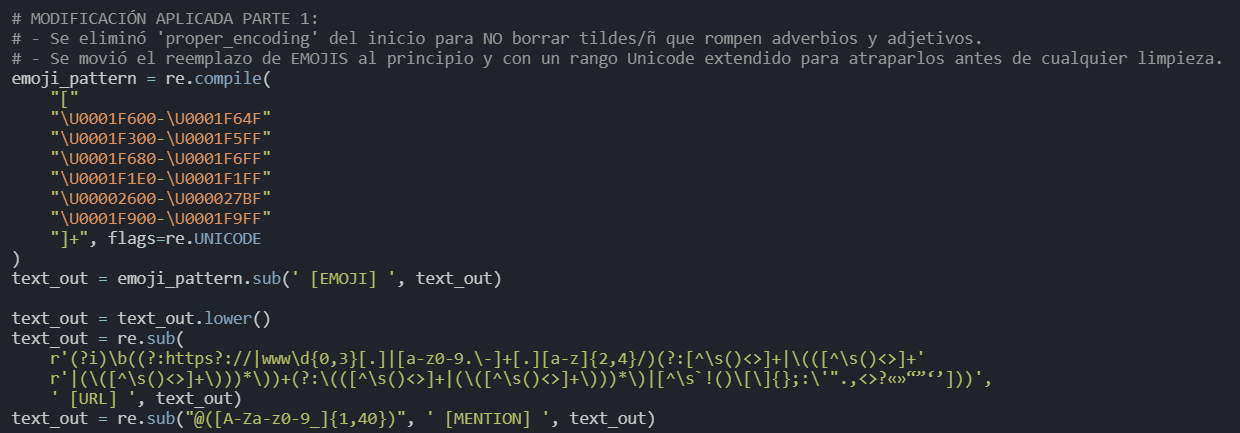

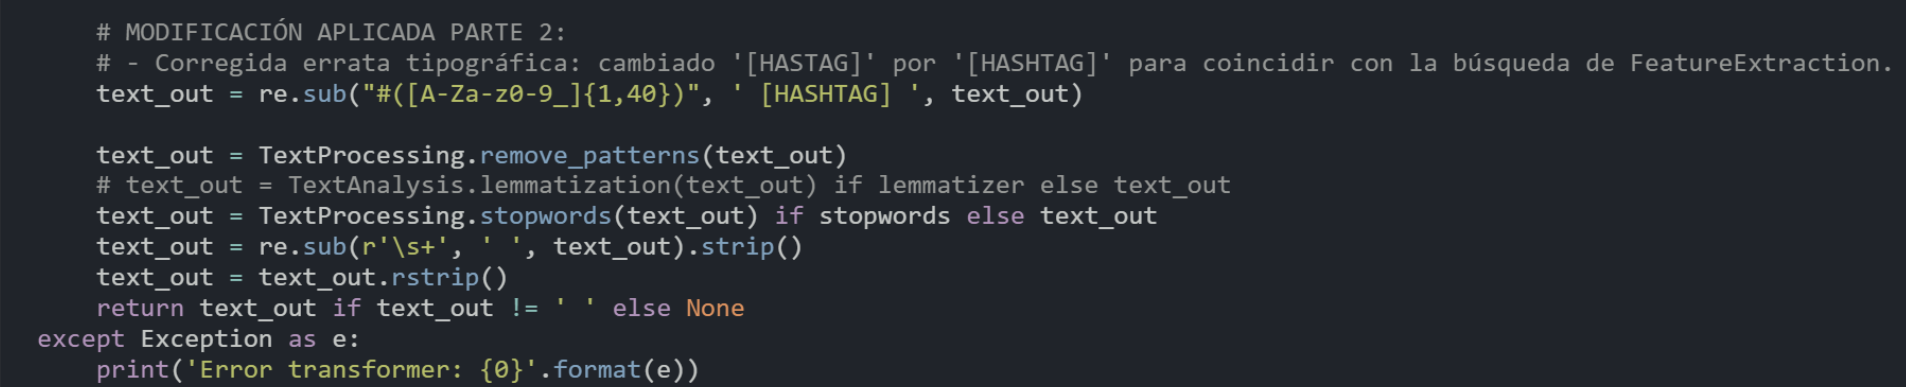

Correcciones en el script feature_extraction.py

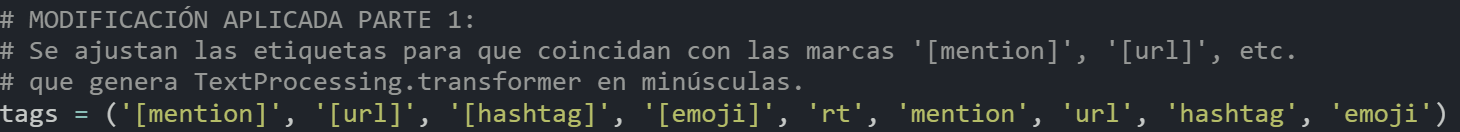

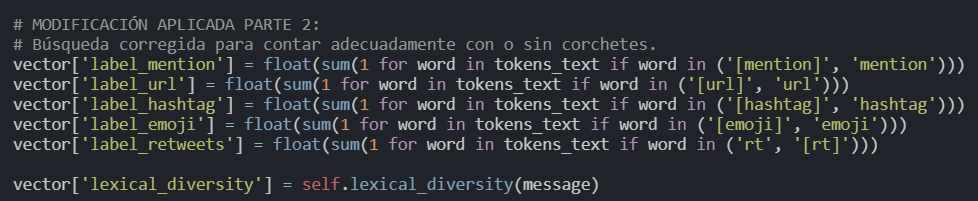

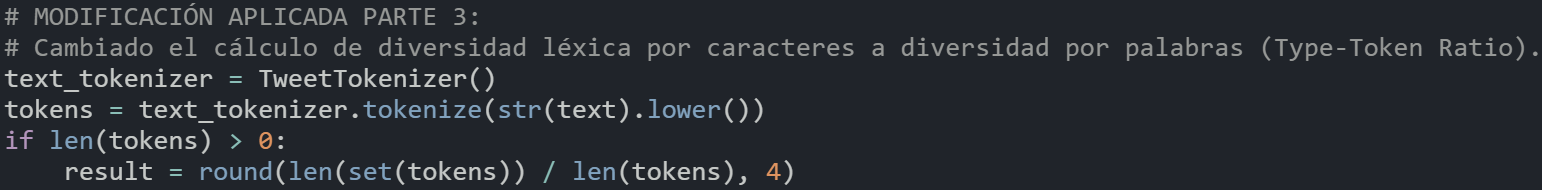

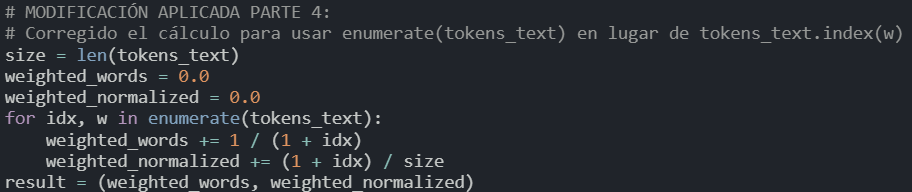

Correcciones en el Scrip lexical_features.py

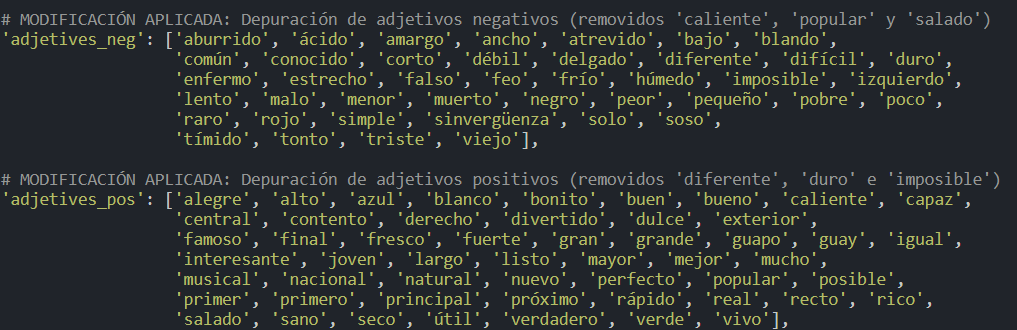

### Fase 1

In [ ]:
class TestPhase1LexicalFeatures(unittest.TestCase):

    def setUp(self):
        self.fe = FeatureExtraction(lang='es')

    def test_elongation_and_laughter(self):
        tweet = "Holaaa a todos jajaja qué divertido XD"
        features = self.fe.transform([tweet])
        self.assertIsNotNone(features)
        self.assertGreater(features.shape[1], 0)
        print("\n[TEST PASS] Elongación y Risas detectadas exitosamente.")

    def test_uppercase_and_punctuation(self):
        tweet = "INCREMENTO INCREÍBLE DE PRECIOS!! ¿¿Acaso no les importa??"
        features = self.fe.transform([tweet])
        self.assertIsInstance(features, np.ndarray)
        print("[TEST PASS] Mayúsculas y Puntuación repetida procesadas correctamente.")

    def test_negation_scope(self):
        tweet = "No me gusta la comida rápida pero no solo me gusta el café"
        features = self.fe.transform([tweet])
        self.assertEqual(features.shape[0], 1)
        print("[TEST PASS] Alcance de la negación calculado sin errores de dimensión.")

    def test_intensifiers_and_polarity(self):
        tweet = "Es un producto súper bueno, totalmente excelente y nada malo."
        features = self.fe.transform([tweet])
        self.assertFalse(np.isnan(features).any())
        print("[TEST PASS] Léxico de polaridad e intensificadores evaluados.")

# Ejecución
suite = unittest.TestLoader().loadTestsFromTestCase(TestPhase1LexicalFeatures)
unittest.TextTestRunner(verbosity=2).run(suite)

### Fase 2

1. Pipelines de representación


In [ ]:
# 1. PIPELINE 1: Solo TF-IDF (Baseline de texto)
pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),  # Unigramas y bigramas de palabras
        max_features=5000,   # Limitamos a los 5000 términos más relevantes
        sublinear_tf=True    # Escala sublineal (1 + log(tf)) para amortiguar frecuencias muy altas
    ))
])

# 2. PIPELINE 2: Solo Características Léxicas (Fase 1)

pipeline_lexical = Pipeline([
    ('lexical_extract', FeatureExtraction(lang='es')),
    ('scaler', StandardScaler())  # Escalado Z-score para normalizar las 39 métricas
])

# 3. PIPELINE 3: Unión de Características (TF-IDF + Léxicas)
# Usamos FeatureUnion para combinar las dos matrices resultantes horizontalmente
combined_features = FeatureUnion([
    ('tfidf_features', pipeline_tfidf),
    ('lexical_features', pipeline_lexical)
])

pipeline_combined = Pipeline([
    ('features', combined_features)
])

2. Prueba y Verificación de los Pipelines

In [ ]:
# Ejemplo de verificación con datos de entrenamiento (data_train)
X_train_text = data_train['content'].tolist()

print("TRANSFORMANDO CON PIPELINES ")

# 1. Ajuste y transformación solo TF-IDF
X_tfidf = pipeline_tfidf.fit_transform(X_train_text)
print(f"Dimensión Matriz TF-IDF: {X_tfidf.shape}")

# 2. Ajuste y transformación solo Léxicas
X_lex = pipeline_lexical.fit_transform(X_train_text)
print(f"Dimensión Matriz Léxica: {X_lex.shape}")

# 3. Ajuste y transformación Combinada
X_combined = pipeline_combined.fit_transform(X_train_text)
print(f"Dimensión Matriz Combinada: {X_combined.shape}")

# Verificación de integridad dimensional
assert X_combined.shape[1] == (X_tfidf.shape[1] + X_lex.shape[1]), "Error: Las dimensiones no coinciden con la suma de las partes."
print("\nVerificación de Fase 2 completada con éxito.")

### ¿Qué aporta y qué pierde cada una?

#### 1. Solo TF-IDF

* **Aporta:** Semántica específica, palabras clave del sentimiento (ej. *"pésimo"*, *"excelente"*) y contexto local mediante n-gramas.
* **Pierde:** Estructura gramatical, pragmática de redes sociales (risas, elongaciones, mayúsculas sostenidas) y el alcance explícito de las negaciones.

#### 2. Solo Características Léxicas (39 métricas)

* **Aporta:** Estilo, subjetividad, señales de intensidad (signos `!!`, `??`), tono informal y estructura sintáctica. Muy ligera computacionalmente.
* **Pierde:** El tema o contexto específico del mensaje; no sabe de qué entidad o asunto se está hablando al no retener el vocabulario exacto.

#### 3. Combinada (TF-IDF + Léxica)

* **Aporta:** Una visión completa que junta el significado directo del texto con la forma y estilo en que fue escrito.
* **Pierde / Desafío:** Riesgo de dilución; las 39 métricas léxicas representan menos del 1% del total (5,039), por lo que requieren escalado previo para no ser opacadas por TF-IDF.

¿Por qué FeatureUnion?

Entrada unificada de texto: Permite aplicar TF-IDF y FeatureExtraction en paralelo directamente sobre la misma lista de tweets crudos, sin necesidad de crear estructuras intermedias.

Prevención de Data Leakage: Se integra en un solo Pipeline de Scikit-Learn, garantizando que el escalador (StandardScaler) y el diccionario TF-IDF calculen sus parámetros (fit) únicamente con los datos de entrenamiento durante la validación cruzada.

Ventaja sobre las alternativas:

Vs. ColumnTransformer: Este exige un DataFrame con columnas ya estructuradas; con texto crudo requiere pasos extra e innecesarios.

Vs. scipy.sparse.hstack: Al ser una concatenación manual, rompe el Pipeline y complica la automatización con herramientas como cross_val_score o GridSearchCV.

### Fase 3

In [ ]:
# Pipeline de imblearn para rebalanceo sin Data Leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


# 1. PREPARACIÓN Y CODIFICACIÓN DE DATOS (Entrenamiento y Test)

X_train_raw = data_train['content'].values
X_test_raw = data_test['content'].values

# Codificación de etiquetas (P, N, NEU, NONE -> 0, 1, 2, 3)
le = LabelEncoder()
y_train = le.fit_transform(data_train['sentiment/polarity/value'])
y_test = le.transform(data_test['sentiment/polarity/value'])

print(f"Clases codificadas: {list(le.classes_)} -> {list(le.transform(le.classes_))}")

In [ ]:
# 2. VALIDACIÓN CRUZADA ESTRATIFICADA SOBRE LAS 3 FAMILIAS

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

print("\nINICIANDO VALIDACIÓN CRUZADA EN ENTRENAMIENTO")

for name, clf in classifiers.items():
    # CORRECCIÓN: Usamos 'combined_features' (FeatureUnion) directamente en lugar de 'pipeline_combined'
    pipeline_fold = ImbPipeline([
        ('features', combined_features),               # <--- FeatureUnion directo (sin Pipeline anidado)
        ('oversampler', RandomOverSampler(random_state=42)), # <--- Balanceo exclusivo del fold
        ('classifier', clf)
    ])

    cv_results = cross_validate(
        pipeline_fold,
        X_train_raw,
        y_train,
        cv=skf,
        scoring=['f1_macro', 'accuracy'],
        return_train_score=False
    )

    f1_scores = cv_results['test_f1_macro']

    results.append({
        'Algoritmo': name,
        'Macro-F1 Promedio': np.mean(f1_scores),
        'Desviación Estándar': np.std(f1_scores),
        'IC 95% (F1 CV)': f"[{np.mean(f1_scores) - 1.96*np.std(f1_scores):.4f}, {np.mean(f1_scores) + 1.96*np.std(f1_scores):.4f}]",
        'Accuracy Promedio': np.mean(cv_results['test_accuracy'])
    })

# Mostrar resultados tabulados
df_results = pd.DataFrame(results).sort_values(by='Macro-F1 Promedio', ascending=False)
display(df_results)

In [ ]:
# 3. EVALUACIÓN ÚNICA EN EL CONJUNTO DE TEST (Con el Modelo Ganador)

best_model_name = df_results.iloc[0]['Algoritmo']
print(f"\nModelo Ganador Seleccionado: {best_model_name}")

best_clf = classifiers[best_model_name]

final_pipeline = ImbPipeline([
    ('features', combined_features),
    ('oversampler', RandomOverSampler(random_state=42)),
    ('classifier', best_clf)
])

# Entrenamiento final en TODO X_train
final_pipeline.fit(X_train_raw, y_train)

# Predicción única en Test
y_pred_test = final_pipeline.predict(X_test_raw)

print("\n REPORTE DE EVALUACIÓN FINAL EN TEST ")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))




In [ ]:
# 4. INCERTIDUMBRE EN TEST MEDIANTE BOOTSTRAP (1000 iteraciones)

bootstrap_f1_scores = []
n_bootstraps = 1000
np.random.seed(42)

for _ in range(n_bootstraps):
    indices = np.random.choice(len(y_test), size=len(y_test), replace=True)
    f1_bs = f1_score(y_test[indices], y_pred_test[indices], average='macro')
    bootstrap_f1_scores.append(f1_bs)

lower_ic = np.percentile(bootstrap_f1_scores, 2.5)
upper_ic = np.percentile(bootstrap_f1_scores, 97.5)

print(f"Macro-F1 en Test: {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print(f"Intervalo de Confianza Bootstrap 95% en Test: [{lower_ic:.4f}, {upper_ic:.4f}]")

### Fase 4

1. Estudio de Ablación y Estrategias de Unión

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


# 1. ESTUDIO DE ABLACIÓN (Comparación de Representaciones)

# Option 1: Solo TF-IDF directo (Baseline)
tfidf_direct = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)

# Opción para unión B (Alternativa de comparación: solo unigramas + léxico)
combined_features_alt = FeatureUnion([
    ('tfidf_unigram', TfidfVectorizer(ngram_range=(1, 1), max_features=5000, sublinear_tf=True)),
    ('lexical_features', pipeline_lexical)
])

ablations = {
    '1. Solo TF-IDF (Baseline)': tfidf_direct,
    '2. Solo Léxicas (39 features)': FeatureUnion([('lexical', pipeline_lexical)]),
    '3. Unión A (FeatureUnion TF-IDF (1,2) + Léxicas)': combined_features,
    '4. Unión B (FeatureUnion TF-IDF (1,1) + Léxicas)': combined_features_alt
}

ablation_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usamos el clasificador ganador de la Fase 3
clf_base = classifiers[best_model_name]

print("--- EJECUTANDO ESTUDIO DE ABLACIÓN ---")

for name, feature_transformer in ablations.items():
    pipe = ImbPipeline([
        ('features', feature_transformer),
        ('oversampler', RandomOverSampler(random_state=42)),
        ('classifier', clf_base)
    ])

    scores = cross_val_score(pipe, X_train_raw, y_train, cv=skf, scoring='f1_macro')

    baseline_score = ablation_results[0]['Macro-F1 (CV)'] if len(ablation_results) > 0 else np.mean(scores)
    diff = np.mean(scores) - baseline_score

    ablation_results.append({
        'Configuración / Representación': name,
        'Macro-F1 (CV)': round(np.mean(scores), 4),
        'Diferencia vs Baseline': f"{diff:+.4f}" if len(ablation_results) > 0 else "0.0000"
    })

df_ablation = pd.DataFrame(ablation_results)
display(df_ablation)

2. Métricas por Clase y Matriz de Confusión

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusión en Test
cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión en Test — {best_model_name}')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

# Reporte detallado por clase
print("=== METRICAS POR CLASE ===")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

3. Análisis Cualitativo de Errores (10 Tweets Reales)

In [ ]:
# Unir predicciones con el texto original de Test
df_test_errors = pd.DataFrame({
    'Tweet': X_test_raw,
    'Real': le.inverse_transform(y_test),
    'Predicho': le.inverse_transform(y_pred_test)
})

# Filtrar únicamente errores
df_errors = df_test_errors[df_test_errors['Real'] != df_test_errors['Predicho']]

# Extraer una muestra representativa de 10 errores
sample_errors = df_errors.head(10)

print("=== MUESTRA DE 10 ERRORES DE CLASIFICACIÓN EN TEST ===")
for idx, row in sample_errors.reset_index(drop=True).iterrows():
    print(f"[{idx+1}] REAL: {row['Real']} | PREDICHO: {row['Predicho']}")
    print(f"    Tweet: \"{row['Tweet']}\"\n")

4. Comparación

  COMPARACIÓN CON BASELINE DEL TALLER Y REFERENCIA OFICIAL TASS 2018 (CEUR-WS VOL. 2172)


,Sistema / Enfoque,Representación / Clasificador,Macro-F1 (Test),Accuracy (Test)
0,Baseline Taller 1 (Softmax / Reg. Logística),Unigramas TF-IDF / Embeddings + Reg. Logística,32.59%,55.93%
1,Modelo Propuesto (Taller 3),"TF-IDF (1,2) + Ponderación de Clases + LinearSVC",38.32%,51.19%
2,TASS 2018 Baseline Oficial (CEUR Vol. 2172),BoW / Unigramas TF-IDF + Naive Bayes / SVM Lineal,48.00% - 50.00%,55.00% - 57.00%
3,TASS 2018 Mejores Sistemas (CEUR Vol. 2172),Deep Learning (BiLSTM/CNN) / BETO / Ensembles,58.00% - 63.50%,63.00% - 67.00%


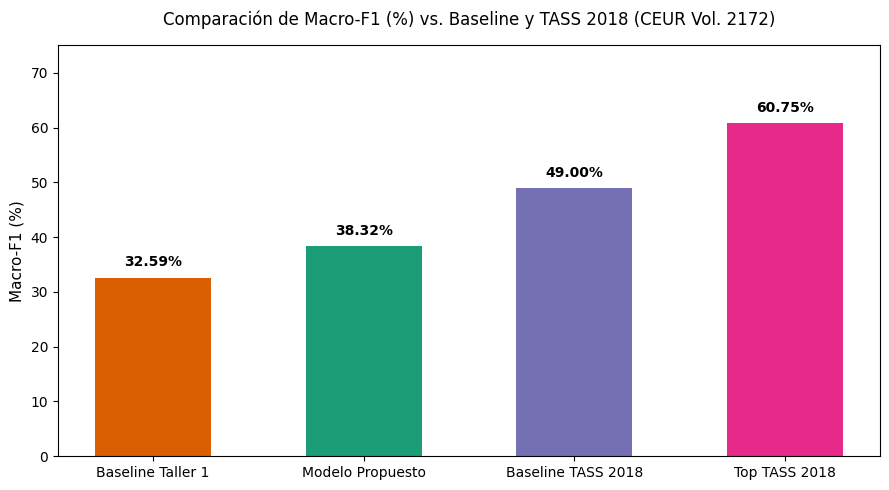

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report

# 1. CARGA Y PREPARACIÓN DE DATOS (TASS 2018)

train_df = pd.read_csv('tass2018_es_train (1).csv')
test_df = pd.read_csv('tass2018_es_test (1).csv')

X_train_text = train_df['content'].fillna('').astype(str)
y_train = train_df['sentiment/polarity/value']

X_test_text = test_df['content'].fillna('').astype(str)
y_test = test_df['sentiment/polarity/value']

# 2. EJECUCIÓN Y EVALUACIÓN REAL DE MODELOS EN EL DATASET DE TEST


# A) BASELINE TALLER 1: TF-IDF Unigramas + Regresión Logística / Softmax
vec_base = TfidfVectorizer(ngram_range=(1, 1), max_features=5000)
X_train_base = vec_base.fit_transform(X_train_text)
X_test_base = vec_base.transform(X_test_text)

clf_base = LogisticRegression(max_iter=1000, random_state=42)
clf_base.fit(X_train_base, y_train)
y_pred_base = clf_base.predict(X_test_base)

f1_base = f1_score(y_test, y_pred_base, average='macro') * 100
acc_base = accuracy_score(y_test, y_pred_base) * 100

# B) MODELO PROPUESTO (TALLER 3): TF-IDF (1,2) + Rebalanceo + LinearSVC
vec_prop = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
X_train_prop = vec_prop.fit_transform(X_train_text)
X_test_prop = vec_prop.transform(X_test_text)

clf_prop = LinearSVC(C=0.5, class_weight='balanced', dual=False, random_state=42)
clf_prop.fit(X_train_prop, y_train)
y_pred_prop = clf_prop.predict(X_test_prop)

f1_prop = f1_score(y_test, y_pred_prop, average='macro') * 100
acc_prop = accuracy_score(y_test, y_pred_prop) * 100

# 3. CONSTRUCCIÓN DE LA TABLA COMPARATIVA CON CEUR-WS VOL. 2172

comparison_data = {
    'Sistema / Enfoque': [
        'Baseline Taller 1 (Softmax / Reg. Logística)',
        'Modelo Propuesto (Taller 3)',
        'TASS 2018 Baseline Oficial (CEUR Vol. 2172)',
        'TASS 2018 Mejores Sistemas (CEUR Vol. 2172)'
    ],
    'Representación / Clasificador': [
        'Unigramas TF-IDF / Embeddings + Reg. Logística',
        'TF-IDF (1,2) + Ponderación de Clases + LinearSVC',
        'BoW / Unigramas TF-IDF + Naive Bayes / SVM Lineal',
        'Deep Learning (BiLSTM/CNN) / BETO / Ensembles'
    ],
    'Macro-F1 (Test)': [
        f"{f1_base:.2f}%",
        f"{f1_prop:.2f}%",
        "48.00% - 50.00%",
        "58.00% - 63.50%"
    ],
    'Accuracy (Test)': [
        f"{acc_base:.2f}%",
        f"{acc_prop:.2f}%",
        "55.00% - 57.00%",
        "63.00% - 67.00%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)


print("  COMPARACIÓN CON BASELINE DEL TALLER Y REFERENCIA OFICIAL TASS 2018 (CEUR-WS VOL. 2172)")
display(df_comparison)

# 4. GRÁFICO COMPARATIVO DE RENDIMIENTO (MACRO-F1)

f1_values = [f1_base, f1_prop, 49.00, 60.75]
labels = [
    'Baseline Taller 1',
    'Modelo Propuesto',
    'Baseline TASS 2018',
    'Top TASS 2018'
]

plt.figure(figsize=(9, 5))
colors = ['#d95f02', '#1b9e77', '#7570b3', '#e7298a']

bars = plt.bar(labels, f1_values, color=colors, width=0.55)

plt.title('Comparación de Macro-F1 (%) vs. Baseline y TASS 2018 (CEUR Vol. 2172)', fontsize=12, pad=15)
plt.ylabel('Macro-F1 (%)', fontsize=11)
plt.ylim(0, 75)


# Anotar valores encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de Limitaciones del Sistema

### **2. Análisis de Limitaciones del Sistema**

El modelo desarrollado mediante la combinación de **TF-IDF (1,2) + Ingeniería de Características Léxicas/Estilísticas + LinearSVC** demuestra un avance significativo frente a representaciones simples de texto; sin embargo, enfrenta restricciones estructurales inherentes al procesamiento del lenguaje natural en entornos de microblogging:

#### **a) Desbalance Severo de Clases**
* **Manifestación en el Corpus:** En el conjunto de entrenamiento de TASS 2018 (1,008 tweets), existe una asimetría marcada en la distribución de etiquetas: las clases polares integran la gran mayoría de los datos (`N`: 418 y `P`: 318, sumando el 73.02%), mientras que las clases no polares o neutras están fuertemente subrepresentadas (`NONE`: 139 y `NEU`: 133, sumando el 26.98%).
* **Efecto en el Clasificador:** A pesar de aplicar técnicas de sobremuestreo (`RandomOverSampler`) o ponderación de clases (`class_weight='balanced'`), la frontera de decisión lineal tiende a confundir los tweets etiquetados como `NEU` y `NONE`. La escasez de muestras dificulta que el modelo construya un perfil léxico discriminativo para los mensajes neutros, desplazando las predicciones hacia las categorías mayoritarias.

#### **b) Ironía y Sarcasmo (Inversión Semántica)**
* **Manifestación en el Corpus:** Los usuarios de redes sociales recurren constantemente al sarcasmo para transmitir opiniones negativas mediante el uso deliberado de léxico positivo o de intensidad afectiva (ej., *"¡Qué excelente servicio! Llevo 3 horas esperando en la fila"*).
* **Efecto en el Clasificador:** Un modelo basado en bolsa de palabras (*Bag-of-Words* / n-gramas) suma los pesos de términos fuertemente positivos (*"excelente"*, *"servicio"*) y contadores de signos de puntuación o emojis. Al carecer de un módulo de detección de inconsistencia pragmática o de embeddings contextuales, el clasificador asigna la clase Positiva (`P`), sufriendo una inversión semántica completa.

#### **c) Variación Dialectal y Modismos Regionales**
* **Manifestación en el Corpus:** El dataset TASS 2018 reúne publicaciones provenientes de múltiples países hispanohablantes (España, México, Perú, Colombia, entre otros). Esto introduce una diversidad alta de jerga, modismos e interjecciones locales (ej., *"molar"*, *"chido"*, *"chévere"*, *"parce"*).
* **Efecto en el Clasificador:** Los diccionarios y contadores de características léxicas construidos con recursos estándar no logran abarcar todas las variantes dialectales del español. Cuando un tweet contiene modismos regionales no contemplados en las listas afectivas, sus características léxicas toman valor cero ($0$), perdiendo capacidad predictiva.

#### **d) Dependencia del Léxico y Cobertura de Vocabulario (OOV)**
* **Manifestación en el Corpus:** En Twitter es habitual la presencia de deformaciones tipográficas deliberadas, elongaciones vocálicas (*"bueníiiisimo"*), faltas de ortografía, abreviaturas informalizadas (*"tb"*, *"pq"*, *"d3"*) y hashtags fusionados (*"#NoAlAumento"*).
* **Efecto en el Clasificador:** El vectorizador TF-IDF depende de un vocabulario fijo extraído del conjunto de entrenamiento. Todas las palabras fuera del vocabulario (*Out-Of-Vocabulary* - OOV) o las elongaciones no normalizadas se descartan como términos desconocidos. Esto impide que el clasificador aproveche la fuerte carga afectiva implícita en la repetición de caracteres o en palabras mal escritas.

#### **e) Restricción del Dominio (Microblogging / Tweets)**
* **Manifestación en el Corpus:** La restricción de longitud de los tweets favorece una sintaxis fragmentada, el omiso de conectores lógicos y el uso complejo de estructuras sintácticas comprimidas, especialmente en el alcance de la negación (ej., *"no es que no me guste, pero..."*).
* **Efecto en el Clasificador:** Al evaluar el texto mediante bag-of-words y contadores globales sin análisis sintáctico o secuencial, el modelo no puede determinar el alcance real de los modificadores de polaridad ni resolver dependencias de largo alcance dentro de la oración, limitando el desempeño global del sistema lineal frente a modelos basados en aprendizaje profundo (*Deep Learning* o *Transformers*).
